# Assignment 5 – Eigenvector Centrality and PageRank Algorithm
### NAME: NIVEDITHA ANUMANDLA

### ROLL NO: U23CS011

This notebook covers:
1. Web graph creation and analysis of SVNIT website
2. Implementation of PageRank on Karate Club dataset

1) Setup Python Environment and install necessary libraries.

In [1]:
# Install required libraries
!pip install networkx matplotlib beautifulsoup4 requests

## Part I – Web Graph of SVNIT Website

2) Write a Python script to fetch the HTML content of the www.svnit.ac.in website and extract
the links.

In [2]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

url = "https://www.svnit.ac.in"
response = requests.get(url)
html_content = response.text
print("Website fetched successfully")

Website fetched successfully


3) Use BeautifulSoup to parse the HTML and extract the hyperlinks.

In [3]:
# Extract internal hyperlinks
soup = BeautifulSoup(html_content, "html.parser")
links = set()

for a_tag in soup.find_all("a", href=True):
    full_url = urljoin(url, a_tag['href'])
    if "svnit.ac.in" in full_url:
        links.add(full_url)

print("Total Internal Links Found:", len(links))

Total Internal Links Found: 387


4) Visualize graph using NetworkX and Matplotlib

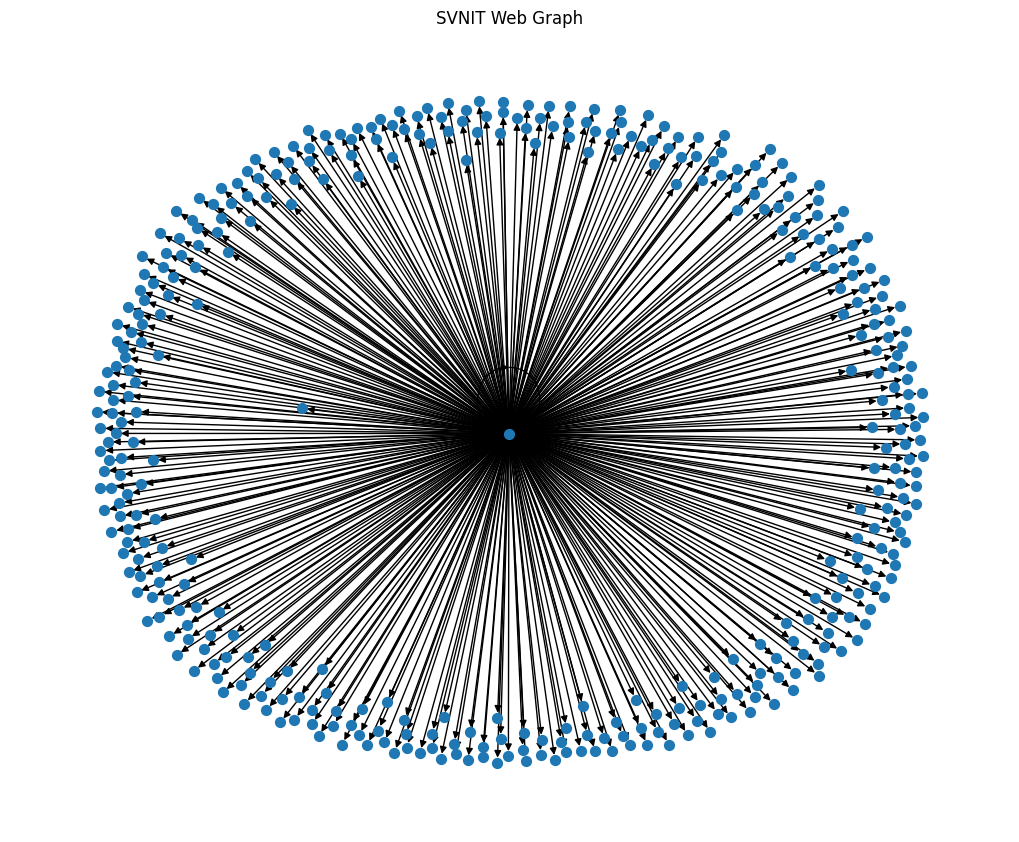

In [5]:
# Visualize Web Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
nx.draw(G_web, with_labels=False, node_size=50)
plt.title("SVNIT Web Graph")
plt.show()

5) Analyze and display following network parameters using NetworkX library:
Number of Nodes, Number of Edges, Indegree and Outdegree distribution chart, Average
indegree and outdegree.

In [6]:
# Create Directed Graph
import networkx as nx

G_web = nx.DiGraph()
for link in links:
    G_web.add_edge(url, link)

print("Nodes:", G_web.number_of_nodes())
print("Edges:", G_web.number_of_edges())

Nodes: 387
Edges: 387


In [7]:
# In-degree and Out-degree Analysis
indegree = dict(G_web.in_degree())
outdegree = dict(G_web.out_degree())

print("Average In-degree:", sum(indegree.values())/len(indegree))
print("Average Out-degree:", sum(outdegree.values())/len(outdegree))

Average In-degree: 1.0
Average Out-degree: 1.0


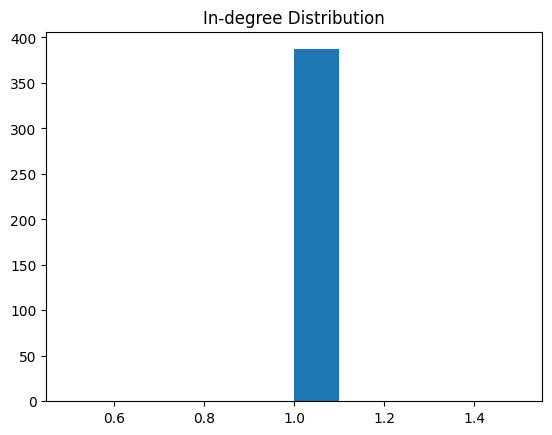

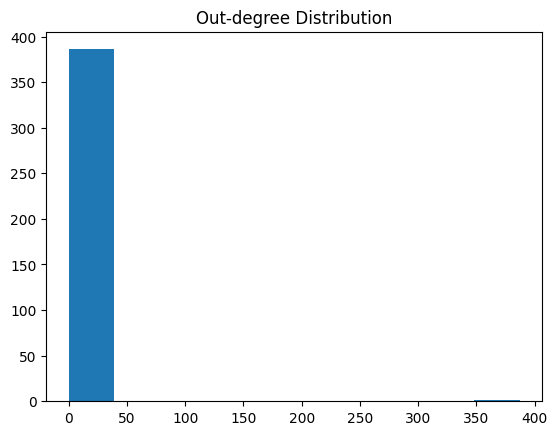

In [8]:
# Degree Distributions
plt.hist(indegree.values(), bins=10)
plt.title("In-degree Distribution")
plt.show()

plt.hist(outdegree.values(), bins=10)
plt.title("Out-degree Distribution")
plt.show()

6) Calculate Eigenvector centrality of each node and display in proper format.

In [9]:
# Eigenvector Centrality
eig_cent = nx.eigenvector_centrality(G_web, max_iter=1000)
sorted_eig = sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)

for node, val in sorted_eig[:10]:
    print(node, ":", round(val, 4))

https://www.svnit.ac.in : 0.0508
https://www.svnit.ac.in/Data/Notice/2025/November/Adobe Scan 25 Nov 2025.pdf : 0.0508
https://www.svnit.ac.in/web/rules_regulations.php : 0.0508
https://www.svnit.ac.in/web/timetable-2026-even.php : 0.0508
https://www.svnit.ac.in/web/supplementary_feb-2025.php : 0.0508
https://www.svnit.ac.in/Data/Notice/2025/June/6.2 Circular for fees payment 26.06.25.pdf : 0.0508
https://www.svnit.ac.in/web/ccc.php : 0.0508
https://svnit.ac.in/Data/Notice/2026/January/Brochure of MATLAB Workshop (1).pdf : 0.0508
https://www.svnit.ac.in/Data/Notice/2025/November/Amendment proj exam.pdf : 0.0508
https://www.svnit.ac.in/Data/Notice/2025/May/Extension Notice.pdf : 0.0508


## Part II – PageRank on Karate Club Graph

1) Implement simple page rank algorithm

In [10]:
# Load Karate Club Graph
G_karate = nx.karate_club_graph()
print("Nodes:", G_karate.number_of_nodes())
print("Edges:", G_karate.number_of_edges())

Nodes: 34
Edges: 78


2) Apply it on the “Karate club graph dataset”

In [11]:
# Compute PageRank
pr = nx.pagerank(G_karate, alpha=0.85)
sorted_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)

print("PageRank Values:")
for node, value in sorted_pr:
    print(node, ":", round(value, 4))

PageRank Values:
33 : 0.097
0 : 0.0885
32 : 0.0759
2 : 0.0628
1 : 0.0574
31 : 0.042
23 : 0.0411
3 : 0.0372
5 : 0.0338
13 : 0.0335
8 : 0.0334
6 : 0.0315
25 : 0.0287
29 : 0.0283
27 : 0.0272
7 : 0.0265
30 : 0.023
10 : 0.0207
4 : 0.0205
16 : 0.0168
24 : 0.0166
15 : 0.0164
26 : 0.0152
28 : 0.0145
19 : 0.0131
22 : 0.013
14 : 0.0129
12 : 0.0115
21 : 0.0114
20 : 0.0112
11 : 0.0098
17 : 0.0097
18 : 0.0095
9 : 0.0095


3) Analyze the graph A. Which node has the highest Page rank

In [12]:
highest_node = max(pr, key=pr.get)
print("Highest PageRank Node:", highest_node)
print("Value:", pr[highest_node])

Highest PageRank Node: 33
Value: 0.09698041880501741


b. What is the lowest page rank in the network

In [13]:
lowest_node = min(pr, key=pr.get)
print("Lowest PageRank Node:", lowest_node)
print("Value:", pr[lowest_node])

Lowest PageRank Node: 9
Value: 0.009463219565799959


c. any other interesting findings

In [14]:
sorted_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)
print("Top 5 Nodes by PageRank:")
for node, value in sorted_pr[:5]:
    print(node, round(value,4))

Top 5 Nodes by PageRank:
33 0.097
0 0.0885
32 0.0759
2 0.0628
1 0.0574


The top-ranked nodes tend to have many connections and act as bridges between communities. PageRank favors nodes that are connected to other important nodes, not just nodes with many links.

d. Does this network has self-loop?

In [16]:
# Check for Self-loops
print("Self-loops:", list(nx.selfloop_edges(G_karate)))

Self-loops: []


e. Display the final page rank vector

In [17]:
for node, value in sorted(pr.items()):
    print(f"Node {node}: {round(value, 5)}")

Node 0: 0.08851
Node 1: 0.05741
Node 2: 0.06277
Node 3: 0.03721
Node 4: 0.0205
Node 5: 0.03381
Node 6: 0.03153
Node 7: 0.02646
Node 8: 0.03338
Node 9: 0.00946
Node 10: 0.02069
Node 11: 0.00979
Node 12: 0.01147
Node 13: 0.03347
Node 14: 0.01294
Node 15: 0.01638
Node 16: 0.01676
Node 17: 0.00968
Node 18: 0.00954
Node 19: 0.01308
Node 20: 0.01122
Node 21: 0.01136
Node 22: 0.01296
Node 23: 0.04115
Node 24: 0.01663
Node 25: 0.02867
Node 26: 0.01524
Node 27: 0.02724
Node 28: 0.01448
Node 29: 0.02827
Node 30: 0.02303
Node 31: 0.04199
Node 32: 0.07593
Node 33: 0.09698
